In [2]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the model you saved in Task 2
best_xgb = joblib.load('../models/best_fraud_model.joblib')

# 2. Load the preprocessor (needed to get feature names)
preprocessor = joblib.load('../data/processed/preprocessor.joblib')

# 3. Load the test data to run the SHAP analysis on
X_test, y_test = joblib.load('../data/processed/test_data_transformed.joblib')

# 4. Extract feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

print("Model and Data loaded successfully!")

Model and Data loaded successfully!


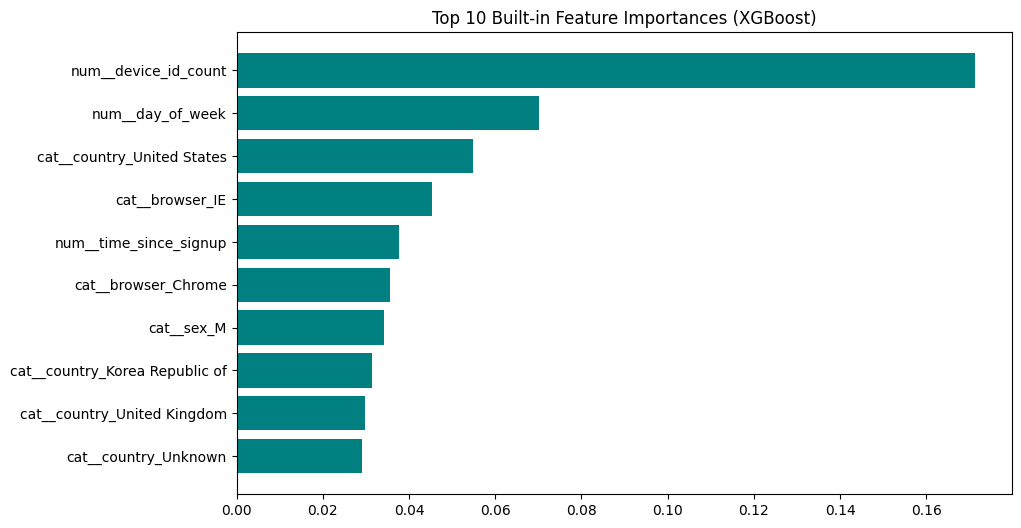

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract built-in importance from your XGBoost model
importances = best_xgb.feature_importances_
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='teal')
plt.title('Top 10 Built-in Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

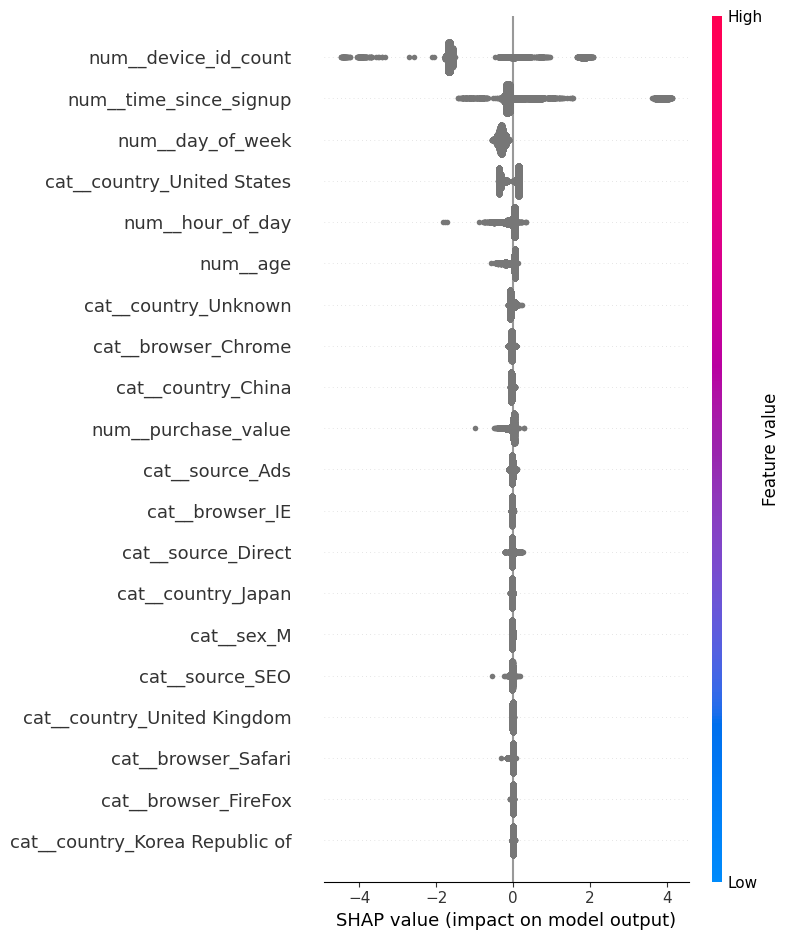

In [4]:
import shap

# Initialize the explainer
explainer = shap.TreeExplainer(best_xgb)
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

Test labels shape: (30223,)
Predictions shape: (30223,)
Generating True Positive Force Plot...


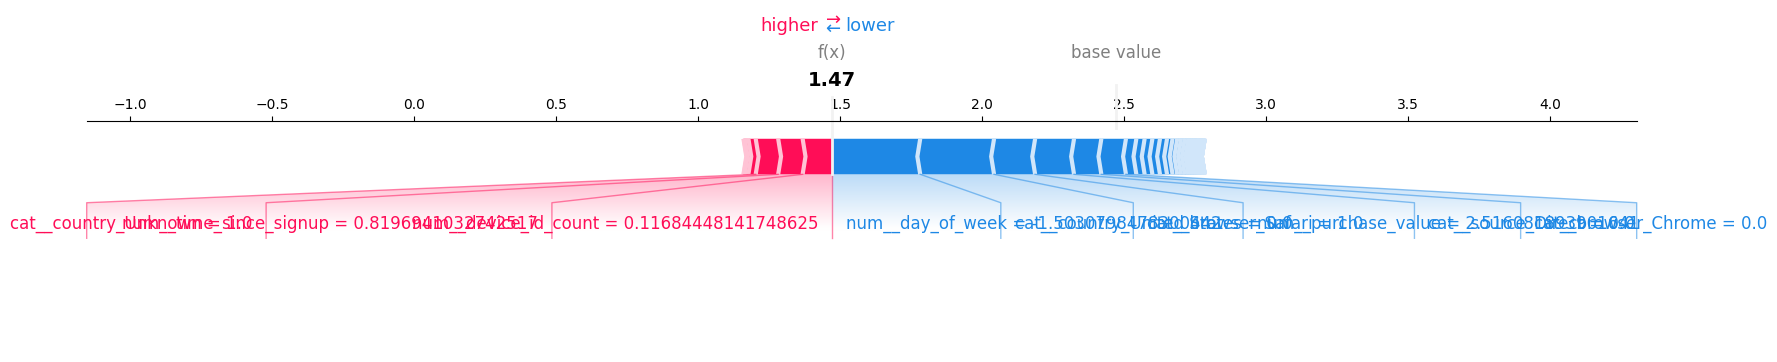

Generating True Positive Plot for index: 2


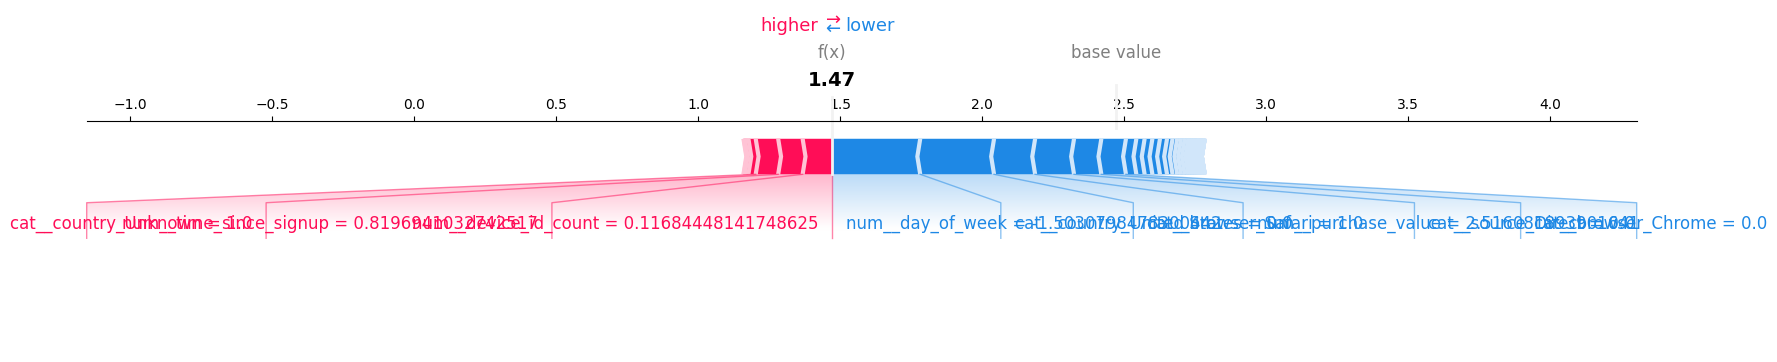

Generating False Positive Plot for index: 7


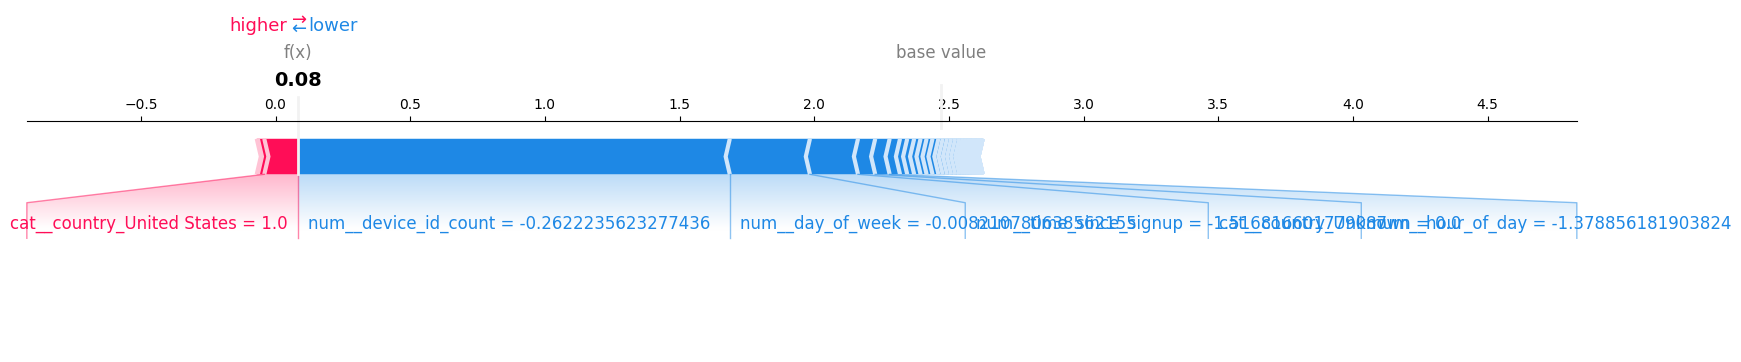

Generating False Negative Plot for index: 56


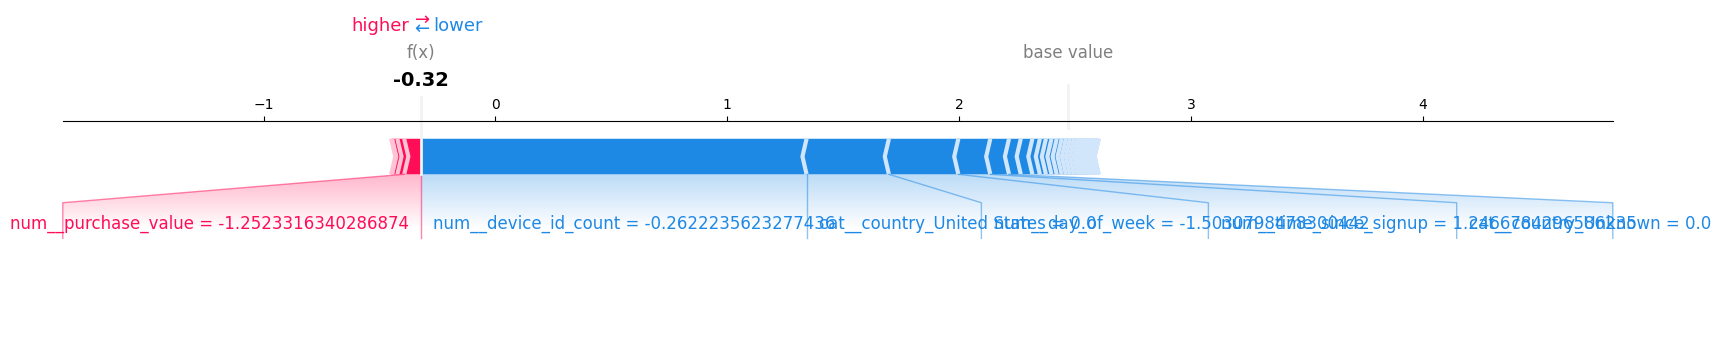

In [12]:
# Generate predictions using the loaded model
y_pred_xgb = best_xgb.predict(X_test)

# Optional: verify the shapes to ensure they match
print(f"Test labels shape: {y_test.shape}")
print(f"Predictions shape: {y_pred_xgb.shape}")

#  Function to get specific indices
def get_index(y_true, y_pred, target_true, target_pred):
    return [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t == target_true and p == target_pred][0]
# 1. Convert the sparse test set to a dense array once
# This allows SHAP to read the feature lengths correctly
if hasattr(X_test, "toarray"):
    X_test_dense = X_test.toarray()
else:
    X_test_dense = X_test

# 2. Get the indices again to be safe
idx_tp = get_index(y_test, y_pred_xgb, 1, 1)
idx_fp = get_index(y_test, y_pred_xgb, 0, 1)
idx_fn = get_index(y_test, y_pred_xgb, 1, 0)

# 3. Generate the True Positive Force Plot
# We use X_test_dense[idx_tp] so SHAP can access the values properly
print("Generating True Positive Force Plot...")
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx_tp], 
    X_test_dense[idx_tp], 
    feature_names=feature_names, 
    matplotlib=True
)
# 1. Ensure you have the dense version of the full test set
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test

# 2. Force Plot: True Positive (Correctly identified Fraud)
idx_tp = get_index(y_test, y_pred_xgb, 1, 1)
print(f"Generating True Positive Plot for index: {idx_tp}")
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx_tp], 
    X_test_dense[idx_tp], # Passing a dense row
    feature_names=feature_names, 
    matplotlib=True
)

# 3. Force Plot: False Positive (Legitimate flagged as Fraud)
idx_fp = get_index(y_test, y_pred_xgb, 0, 1)
print(f"Generating False Positive Plot for index: {idx_fp}")
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx_fp], 
    X_test_dense[idx_fp], 
    feature_names=feature_names, 
    matplotlib=True
)

# 4. Force Plot: False Negative (Missed Fraud)
idx_fn = get_index(y_test, y_pred_xgb, 1, 0)
print(f"Generating False Negative Plot for index: {idx_fn}")
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx_fn], 
    X_test_dense[idx_fn], 
    feature_names=feature_names, 
    matplotlib=True
)